# Classification automatique des biens de consommations

## Préparation de l'environnement et chargement des données

In [1]:
#imports essentiels
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
from src.data_utils.data_loader import load_and_validate
from src.data_utils.data_validator import get_data_summary
#from src.data_utils.data_validator import analyze_missing_values

In [3]:
df = load_and_validate('data/raw/flipkart.csv')

Fichier non trouvé:data/raw/flipkart.csv


In [4]:
df = load_and_validate("C:/Users/hajer/Documents/4-project_git/e_commerce_product_classification_with_Python/data/raw/flipkart_com-ecommerce_sample_1050.csv")

Données chargées avec succès : 1050 lignes, 15 colonnes
les colonnes:list[Index(['uniq_id', 'crawl_timestamp', 'product_url', 'product_name',
       'product_category_tree', 'pid', 'retail_price', 'discounted_price',
       'image', 'is_FK_Advantage_product', 'description', 'product_rating',
       'overall_rating', 'brand', 'product_specifications'],
      dtype='object')]


In [5]:
summary1, summary2 = get_data_summary(df)

In [6]:
summary1

,Nombre de lignes,Nombre de colonnes,% de valeurs manquantes
0,1050,15,32.48


In [7]:
summary2

,Feature,Unique_values,Percentage of missing values,type
0,uniq_id,1050,0.000000,object
1,crawl_timestamp,149,0.000000,object
2,product_url,1050,0.000000,object
3,product_name,1050,0.000000,object
4,product_category_tree,642,0.000000,object
5,pid,1050,0.000000,object
6,retail_price,354,0.095238,float64
7,discounted_price,424,0.095238,float64
8,image,1050,0.000000,object
9,is_FK_Advantage_product,2,0.000000,bool


## Analyse exploratoire des données

In [8]:
from src.data_utils.data_validator import analyze_missing_values

In [9]:
def plot_price_distribution(df, price_col='retail_price', title = "Distribution des prix"):
    """
    Visualise la distribution des prix, sans outliers
    """
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))

    sns.boxplot(y=price_col, data=df, ax=axes[0])
    axes[0].set_title(f"{title} - Vue complète")
    # Distribution sans outliers (méthode du Z-score)
    Q3 = df[price_col].quantile(0.75)
    Q1 = df[price_col].quantile(0.25)
    IQR = Q3 - Q1
    upper_bound = Q3 + 3 * IQR

    sns.boxplot(y=price_col, data=df[df[price_col]<=upper_bound], ax=axes[1])
    axes[1].set_title(f"{title} - Sans outliers extrêmes")

    plt.tight_layout() #Automatically adjust subplot parameters to give specified padding.
    plt.show()

def analyze_brands(df, brand_col='brand', top_n=15):
    """
    Analyse des marques avec gestion des valeurs manquantes
    """
    #Nettoyage des valeurs manquantes
    df_clean = df.dropna(subset=[brand_col])

    #Top des marques par nombre de produits
    brand_counts = df_clean[brand_col].value_counts().head(top_n)

    # Prix moyen par nombre de produits
    avg_prices = df_clean.groupby(by=brand_col)['retail_price'].mean().sort_values(ascending=False).head(10)

    return brand_counts, avg_prices

def plot_brand_analysis(brand_counts, avg_prices):
    """
    Visualise l'analyse des marques
    """
    # Nombre de produits par marque
    fig, axes = plt.subplots(2, 1, figsize = (12, 10))
    brand_counts.plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Top 15 des nombre de produits par marque', fontsize=14)
    axes[0].set_xlabel('Marques')
    axes[0].set_ylabel('Nombre de produits')
    axes[0].tick_params(axis='x', rotation=45)

    #Pris moyen par marque
    avg_prices.plot(kind='bar', ax=axes[1], color='lightcoral')
    axes[1].set_title('Top 10 - Prix moyen par marque', fontsize=14)
    axes[1].set_xlabel('Marques')
    axes[1].set_ylabel('Prix moyen')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


In [10]:
missing_analysis = analyze_missing_values(df)
print("Analyse des valeurs manquantes :")
missing_analysis

Analyse des valeurs manquantes :


,Colonne,Valeurs manquantes,Pourcentage
13,brand,338,32.190476
6,retail_price,1,0.095238
7,discounted_price,1,0.095238
14,product_specifications,1,0.095238


La seule variable contenant des valeurs manquantes est la colonnes 'brand':Marque

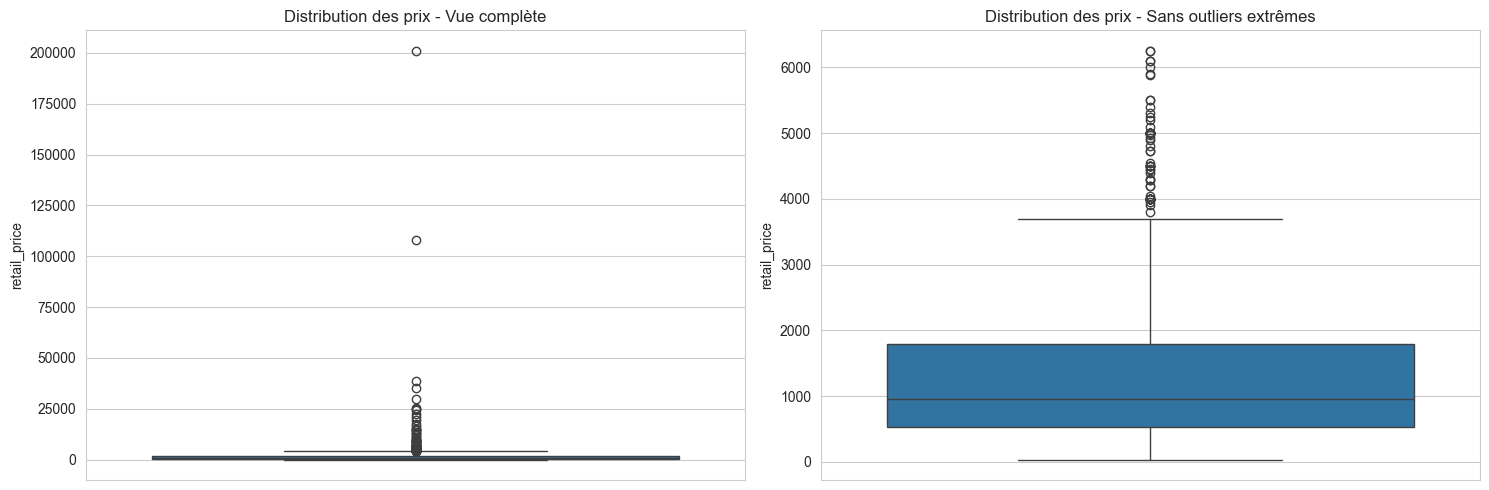

In [11]:
plot_price_distribution(df, price_col='retail_price', title="Distribution des prix")

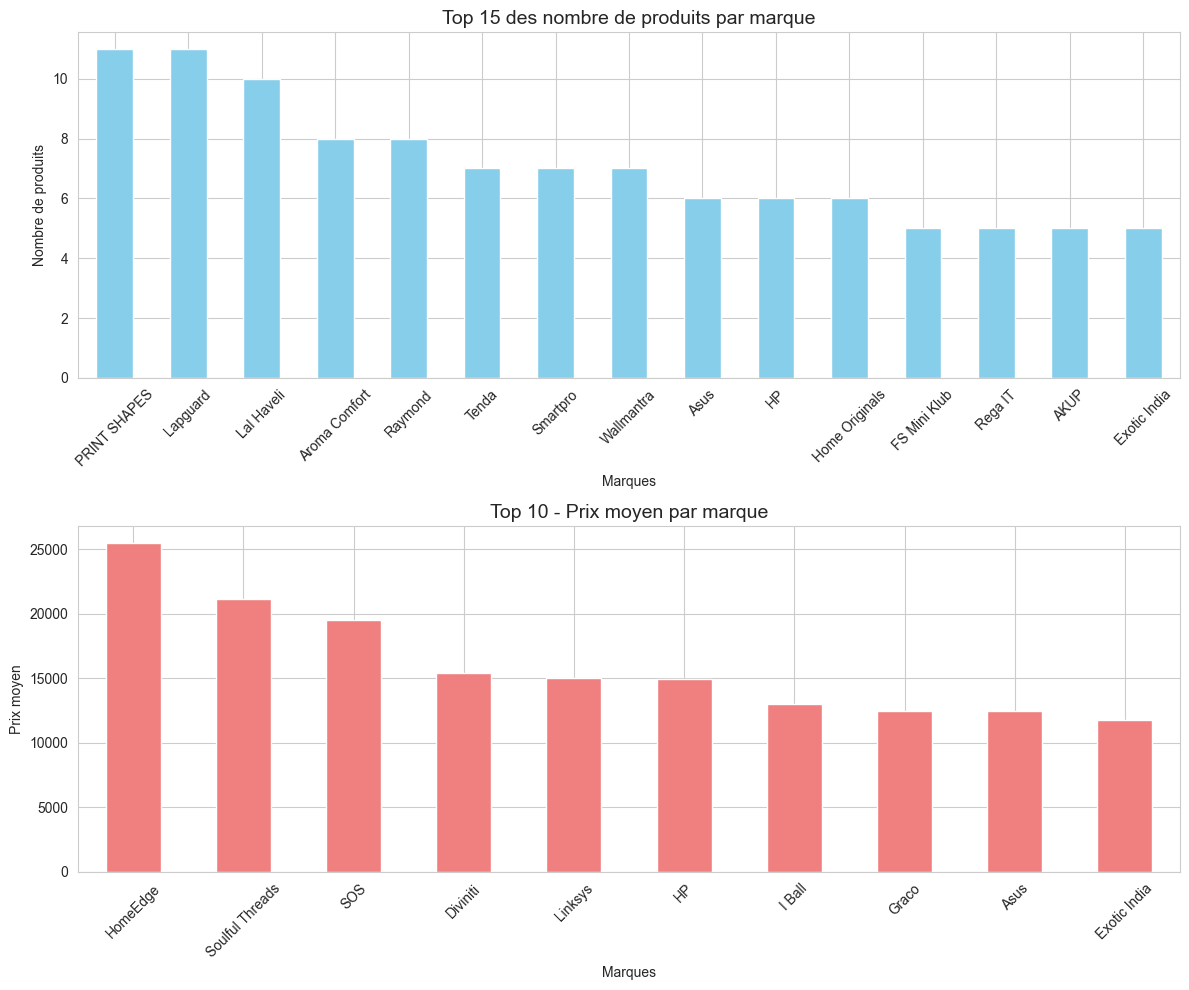

In [12]:
brand_counts, avg_prices = analyze_brands(df)
plot_brand_analysis(brand_counts, avg_prices)

- **HomeEdge** : Mobilier maison 
- **Soulful Threads** : vetements
- **SOS** : Chaussures
- **Divinti** : Bijoux
- **Exotic India** : décoration indienne

In [13]:
df.describe()

,retail_price,discounted_price
count,1049.000000,1049.000000
mean,2186.197331,1584.527169
std,7639.229411,7475.099680
min,35.000000,35.000000
25%,555.000000,340.000000
50%,999.000000,600.000000
75%,1999.000000,1199.000000
max,201000.000000,201000.000000
